# Evaluation and Results

This notebook presents the final chosen CIFAR10-DVS model and the main experimental conclusions of the project.

## Goals

- summarize the final selected model and preprocessing setup
- present the final training and validation curves
- present the main quantitative results
- compare the final model against the most important alternatives
- provide report-ready conclusions

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROJECT_ROOT

PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject')

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from snn_cifar10dvs.train import TrainingEpochResult

## Final Model Summary

In [3]:
final_model_summary = {
    "selected_experiment": "wider_10bins_10epochs",
    "dataset": "CIFAR10-DVS",
    "input_representation": "Frame-based event representation",
    "n_time_bins": 10,
    "polarities": 2,
    "normalization": True,
    "model_type": "Wider hybrid CNN + SNN",
    "conv_channels": (32, 64, 128),
    "hidden_features": 512,
    "dropout": 0.3,
    "epochs": 10,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "weight_decay": 0.0,
    "batch_size": 4,
    "parameter_count": 1148202,
    "best_checkpoint_epoch": 7,
    "test_accuracy": 0.5293333333333333,
    "checkpoint": "outputs/checkpoints/wider_10bins_10epochs.pt",
}

final_model_summary

{'selected_experiment': 'wider_10bins_10epochs',
 'dataset': 'CIFAR10-DVS',
 'input_representation': 'Frame-based event representation',
 'n_time_bins': 10,
 'polarities': 2,
 'normalization': True,
 'model_type': 'Wider hybrid CNN + SNN',
 'conv_channels': (32, 64, 128),
 'hidden_features': 512,
 'dropout': 0.3,
 'epochs': 10,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'weight_decay': 0.0,
 'batch_size': 4,
 'parameter_count': 1148202,
 'best_checkpoint_epoch': 7,
 'test_accuracy': 0.5293333333333333,
 'checkpoint': 'outputs/checkpoints/wider_10bins_10epochs.pt'}

## Final Training History

These values correspond to the selected `wider_10bins_10epochs` experiment.

In [4]:
history = [
    TrainingEpochResult(epoch=1, train_loss=2.1245, train_accuracy=0.1954, validation_loss=1.9378, validation_accuracy=0.2633),
    TrainingEpochResult(epoch=2, train_loss=1.8513, train_accuracy=0.3214, validation_loss=1.7727, validation_accuracy=0.3587),
    TrainingEpochResult(epoch=3, train_loss=1.6719, train_accuracy=0.3924, validation_loss=1.6034, validation_accuracy=0.4073),
    TrainingEpochResult(epoch=4, train_loss=1.5216, train_accuracy=0.4477, validation_loss=1.5530, validation_accuracy=0.4493),
    TrainingEpochResult(epoch=5, train_loss=1.3848, train_accuracy=0.5050, validation_loss=1.4627, validation_accuracy=0.4960),
    TrainingEpochResult(epoch=6, train_loss=1.2572, train_accuracy=0.5547, validation_loss=1.5102, validation_accuracy=0.4787),
    TrainingEpochResult(epoch=7, train_loss=1.1488, train_accuracy=0.5890, validation_loss=1.4319, validation_accuracy=0.5080),
    TrainingEpochResult(epoch=8, train_loss=1.0167, train_accuracy=0.6431, validation_loss=1.4770, validation_accuracy=0.5180),
    TrainingEpochResult(epoch=9, train_loss=0.9126, train_accuracy=0.6834, validation_loss=1.4702, validation_accuracy=0.5393),
    TrainingEpochResult(epoch=10, train_loss=0.7954, train_accuracy=0.7200, validation_loss=1.5040, validation_accuracy=0.5313),
]

history

[TrainingEpochResult(epoch=1, train_loss=2.1245, train_accuracy=0.1954, validation_loss=1.9378, validation_accuracy=0.2633),
 TrainingEpochResult(epoch=2, train_loss=1.8513, train_accuracy=0.3214, validation_loss=1.7727, validation_accuracy=0.3587),
 TrainingEpochResult(epoch=3, train_loss=1.6719, train_accuracy=0.3924, validation_loss=1.6034, validation_accuracy=0.4073),
 TrainingEpochResult(epoch=4, train_loss=1.5216, train_accuracy=0.4477, validation_loss=1.553, validation_accuracy=0.4493),
 TrainingEpochResult(epoch=5, train_loss=1.3848, train_accuracy=0.505, validation_loss=1.4627, validation_accuracy=0.496),
 TrainingEpochResult(epoch=6, train_loss=1.2572, train_accuracy=0.5547, validation_loss=1.5102, validation_accuracy=0.4787),
 TrainingEpochResult(epoch=7, train_loss=1.1488, train_accuracy=0.589, validation_loss=1.4319, validation_accuracy=0.508),
 TrainingEpochResult(epoch=8, train_loss=1.0167, train_accuracy=0.6431, validation_loss=1.477, validation_accuracy=0.518),
 Traini

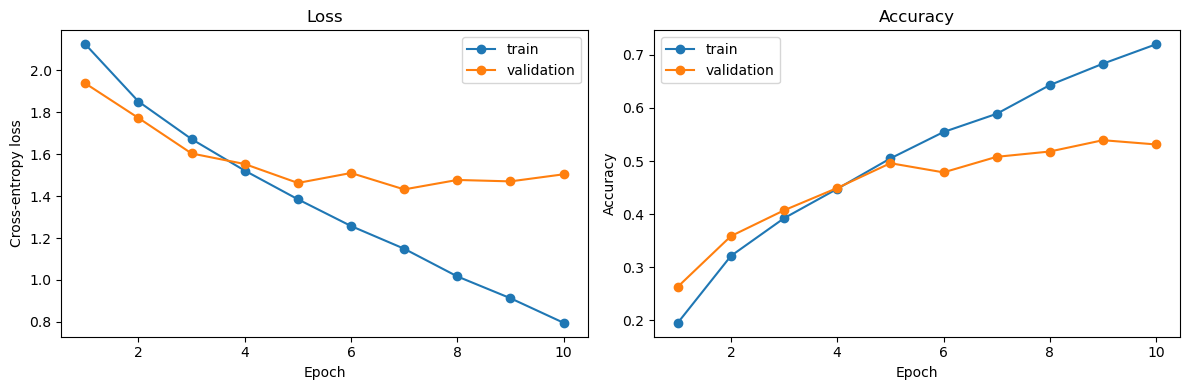

In [5]:
epochs = [entry.epoch for entry in history]
train_loss = [entry.train_loss for entry in history]
validation_loss = [entry.validation_loss for entry in history]
train_accuracy = [entry.train_accuracy for entry in history]
validation_accuracy = [entry.validation_accuracy for entry in history]

figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, train_loss, marker="o", label="train")
axes[0].plot(epochs, validation_loss, marker="o", label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].legend()

axes[1].plot(epochs, train_accuracy, marker="o", label="train")
axes[1].plot(epochs, validation_accuracy, marker="o", label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

figure.tight_layout()
plt.show()

## Final Quantitative Results

In [6]:
final_metrics = {
    "test_accuracy": 0.5293333333333333,
    "best_checkpoint_epoch": 7,
    "final_epoch_train_accuracy": 0.7200,
    "final_epoch_validation_accuracy": 0.5313,
    "weighted_precision": 0.5544183022304174,
    "weighted_recall": 0.5293333333333333,
    "weighted_f1": 0.528303888451771,
}

final_metrics

{'test_accuracy': 0.5293333333333333,
 'best_checkpoint_epoch': 7,
 'final_epoch_train_accuracy': 0.72,
 'final_epoch_validation_accuracy': 0.5313,
 'weighted_precision': 0.5544183022304174,
 'weighted_recall': 0.5293333333333333,
 'weighted_f1': 0.528303888451771}

## Experiment Comparison Summary

In [7]:
comparison_rows = [
    {
        "experiment": "baseline_10bins_5epochs",
        "description": "Initial hybrid CNN + SNN baseline",
        "test_accuracy": 0.4940,
        "main_takeaway": "Good starting point; proves the full pipeline works.",
    },
    {
        "experiment": "wider_10bins_10epochs",
        "description": "Final selected wider hybrid CNN + SNN",
        "test_accuracy": 0.5293333333333333,
        "main_takeaway": "Best overall result and final chosen model.",
    },
    {
        "experiment": "wider_10bins_wd1e4_10epochs",
        "description": "Wider model with weight decay 1e-4",
        "test_accuracy": 0.5086666666666667,
        "main_takeaway": "Reduced overfitting somewhat, but also reduced final performance.",
    },
    {
        "experiment": "nengo_like_10bins_10epochs",
        "description": "More SNN-heavy conv + spiking architecture",
        "test_accuracy": 0.2960,
        "main_takeaway": "Underfit badly; more spiking throughout did not help in this form.",
    },
    {
        "experiment": "wider_10bins_15epochs",
        "description": "Longer training for the wider hybrid model",
        "test_accuracy": 0.5273333333333333,
        "main_takeaway": "Training longer increased overfitting without improving generalization.",
    },
]

comparison_df = pd.DataFrame(comparison_rows).sort_values("test_accuracy", ascending=False)
comparison_df

,experiment,description,test_accuracy,main_takeaway
1,wider_10bins_10epochs,Final selected wider hybrid CNN + SNN,0.529333,Best overall result and final chosen model.
4,wider_10bins_15epochs,Longer training for the wider hybrid model,0.527333,Training longer increased overfitting without ...
2,wider_10bins_wd1e4_10epochs,Wider model with weight decay 1e-4,0.508667,"Reduced overfitting somewhat, but also reduced..."
0,baseline_10bins_5epochs,Initial hybrid CNN + SNN baseline,0.494000,Good starting point; proves the full pipeline ...
3,nengo_like_10bins_10epochs,More SNN-heavy conv + spiking architecture,0.296000,Underfit badly; more spiking throughout did no...


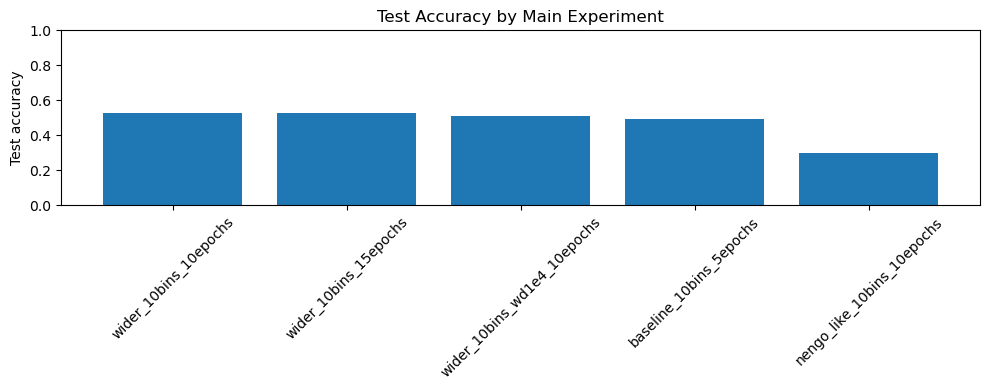

In [8]:
figure, axis = plt.subplots(figsize=(10, 4))
axis.bar(comparison_df["experiment"], comparison_df["test_accuracy"])
axis.set_title("Test Accuracy by Main Experiment")
axis.set_ylabel("Test accuracy")
axis.set_ylim(0.0, 1.0)
axis.tick_params(axis="x", rotation=45)
figure.tight_layout()
plt.show()

## Interpretation

### Main observations

- The final chosen model reaches about `52.9%` test accuracy on CIFAR10-DVS.
- Increasing model capacity improved performance relative to the smaller baseline.
- Stronger regularization with `weight_decay = 1e-4` did not improve the final result.
- A more SNN-heavy Nengo-inspired architecture performed much worse than the stronger hybrid model.
- Training the wider model for `15` epochs increased training fit but did not improve generalization.

### Why the final model was chosen

- It achieved the highest test accuracy among the tested variants.
- It improved clearly over the original baseline.
- It kept the architecture understandable and appropriate for a university project.
- It provided the best tradeoff between performance, simplicity, and reproducibility.

### Practical takeaway

- For this project, a stronger hybrid CNN + SNN model worked better than making the architecture more aggressively spiking.
- CIFAR10-DVS is a difficult event-based dataset, so moderate accuracy is normal and should be interpreted in that context.
- Best-checkpoint evaluation is important, because longer training eventually increases overfitting.

## Final Conclusion

The final project result supports the use of a hybrid event-frame CNN + SNN classifier for CIFAR10-DVS. After comparing preprocessing choices, model capacity, regularization, and a more SNN-heavy architecture, the `wider_10bins_10epochs` model was selected as the final solution. It gave the strongest overall accuracy while remaining clean, reproducible, and suitable for analysis in a course-project setting.

## Possible Future Work

- test milder regularization values such as `weight_decay = 1e-5`
- add a learning-rate schedule
- explore GroupNorm or LayerNorm instead of BatchNorm in the low-batch-size setting
- test alternative event representations or stronger augmentation
- revisit more SNN-heavy architectures without reducing overall model capacity